# Econometrics I

```
TA Christian Alemán
```

**Session 7: Friday 4, March 2022**

Based on WGreene Ch9.

**Activity 1: Heteroskedasticity**

**Harvey's Model of Multiplicative heteroscedasticity:**

General Formulation:

$$\sigma^{2}_{i}=\sigma^{2}exp(z_{i}'\gamma)$$

1. Then the case we saw last friday:

$$\sigma^{2}_{i}=\sigma^{2}exp(\gamma z_{i})$$

2. And Group Wise heteroscedasticity:

$$\sigma^{2}_{g}=\sigma^{2}exp(\gamma_{g})$$

**Consider Cost function for the U.S. airline industry:**

$$ln C_{it} = \beta_{0}+\beta_{1}ln Q_{it}+\beta_{2}ln Q^{2}_{it}+ln PFuel_{it}+\epsilon_{it}$$

$$\epsilon_{i,t}\sim \mathcal{N}(0,\sigma^{2}_{i,t}=\sigma^{2}exp(z_{i,t}'\gamma))$$

$$\sigma^{2}_{i,t}=\sigma^{2}exp(\gamma\, Load Factor_{i,t})$$

$$\sigma^{2}_{i,t}=exp(\gamma_{1}+\gamma_{2} Load Factor_{i,t})\quad\text{with}\quad \gamma_{1}=ln \sigma^{2}$$

Then define the weights as:

$$w_{i,t}=exp(-\gamma_{1}-\gamma_{2} Load Factor_{i,t})$$

To estimate FGLS:

$$y_{i,t} = y_{i,t}/\sqrt{w_{i,t}} \quad\text{and}\quad x_{i,t} = x_{i,t}/\sqrt{w_{i,t}}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def my_ols(y, x):
    '''
    This function computes OLS estimates and
    its standard errors
    inputs: y dependent var
            x independent vars
    outputs: beta   OLS coefficients
             sigma  Estimator or variance of error
             e      Backed residuals
             se     Standard Errors
    '''
    n, k = x.shape
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    e = y - x @ beta
    sigma = (e @ e) / (n - np.linalg.matrix_rank(x))
    VCV = (e @ e) / n * np.linalg.inv(x.T @ x)
    se = np.sqrt(np.diag(VCV))

    # Eicker-White se
    aux = x * (e ** 2)[:, None]
    VCV_white = np.linalg.inv(x.T @ x) @ (x.T @ aux) @ np.linalg.inv(x.T @ x)
    se_rob = np.sqrt(np.diag(VCV_white))

    return beta, sigma, e, se, se_rob


def my_gls(y, x, x_aux=None, het=0, nt=None, nc=None):
    '''
    This function computes GLS estimates and
    its standard errors
    inputs: y dependent var
            x independent vars
    outputs: beta   OLS coefficients
             sigma  Estimator or variance of error
             e      Backed residuals
             se     Standard Errors
    '''
    n, k = x.shape
    if het == 1:
        # Traditional heteroskedasticity
        _, _, e_ols, _, _ = my_ols(y, x)
        e_ols = e_ols ** 2
        # C = diag(1./ sqrt(e_ols));
        L = np.linalg.cholesky(np.linalg.inv(np.diag(e_ols)))
        C = L.T
        beta, _, e, se, _ = my_ols(C @ y, C @ x)
    elif het == 2:
        # AR(1) Errors
        _, _, e_ols, _, _ = my_ols(y, x)
        ey = e_ols[1:n]
        ex = e_ols[0:n - 1]
        rho = (ex @ ey) / (ex @ ex)    # Estimating the autocorrelation coeff
        e_auto = ey - ex * rho
        var_e = e_auto.var(ddof=0)

        sigma_e = np.eye(n)
        for i in range(n):
            for j in range(i + 1, n):
                sigma_e[i, j] = rho ** (j - i)
                sigma_e[j, i] = sigma_e[i, j]
        L = np.linalg.cholesky(np.linalg.inv(sigma_e))
        C = L.T
        beta, _, e, se, _ = my_ols(C @ y, C @ x)
    elif het == 3:
        # Weighted Least Squares:
        _, _, e_ols, _, _ = my_ols(y, x)
        ye = np.log(e_ols ** 2)
        xe = np.column_stack([np.ones(n), x_aux])
        c, _, _, _, _ = my_ols(ye, xe)
        wgt = np.exp(-c[0] - c[1] * x_aux)
        beta, _, e, se, _ = my_ols(y * np.sqrt(wgt), x * np.sqrt(wgt)[:, None])
    else:
        # By group
        _, _, e_ols, _, _ = my_ols(y, x)
        e_aux = e_ols ** 2
        e_aux = e_aux.reshape(nt, nc, order='F')
        e_aux = e_aux.mean(axis=0)
        e_aux = np.tile(e_aux, (nt, 1))
        wgt = 1 / e_aux.flatten(order='F')
        beta, _, e, se, _ = my_ols(y * np.sqrt(wgt), x * np.sqrt(wgt)[:, None])

    return beta, e, se


def my_white(e, x):
    '''
    White's test for heteroscedasticity
    Input:
    e: Residuals
    x: Independent Variables
    '''
    n = e.shape[0]
    k = x.shape[1] - 1
    _, _, e_ols, _, _ = my_ols(e ** 2, x)
    TSS = e ** 2 - (e ** 2).mean()
    TSS = TSS @ TSS
    ESS = e_ols @ e_ols
    rsq = 1 - ESS / TSS
    value = n * rsq
    pvalue = 1 - stats.chi2.cdf(value, k)
    return value, pvalue


def my_BP(e, x):
    '''
    Breusch pagan test for heteroscedasticity
    Input:
    e: Residuals
    x: Independent Variables
    '''
    n = e.shape[0]
    k = x.shape[1]
    g = (e ** 2) / ((e @ e) / n) - 1
    xx_inv = np.linalg.inv(x.T @ x)
    LM = 0.5 * (g @ x @ xx_inv @ x.T @ g)
    crit = stats.chi2.ppf(0.95, k)
    result = 1 if LM > crit else 0   # 1: Reject Ho, 0: Cannot Reject H0
    return result


In [2]:
data_harvey = pd.read_csv('data_harvey.csv')

X = np.column_stack([
    np.ones(len(data_harvey)),
    np.log(data_harvey['Q']),
    np.log(data_harvey['Q']) ** 2,
    np.log(data_harvey['PF']),
])
Y = np.log(data_harvey['C']).to_numpy()
X_aux = data_harvey['LF'].to_numpy()
beta_ols, sigma, e, se_ols, se_rob = my_ols(Y, X)

stat = ['Constant', 'log(Output)', 'log(Output^2)', 'log(Price Fuel)']
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols})
print(t.to_string(index=False))


           stat  beta_ols   se_ols
       Constant  9.138228 0.239559
    log(Output)  0.926149 0.031580
  log(Output^2)  0.029145 0.012027
log(Price Fuel)  0.410060 0.018384


Visual Inspection

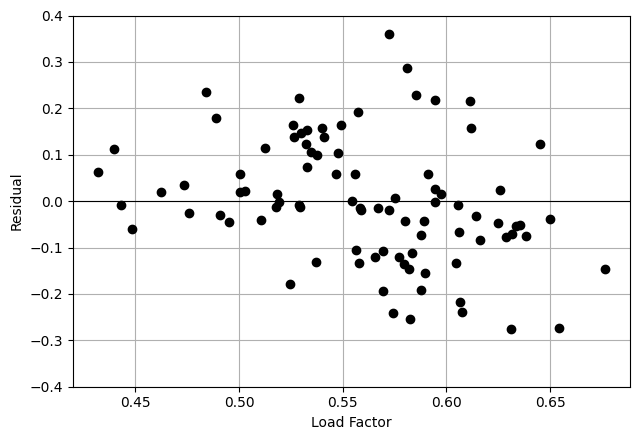

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(X_aux, e, 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.grid(True)
ax.set_ylim(-0.4, 0.4)
ax.set_ylabel('Residual')
ax.set_xlabel('Load Factor')
plt.tight_layout()
plt.show()


**White Test**

$H_{0}:$ Homoscedasticity

In [4]:
print('White Test')
value, pvalue = my_white(e, X)
t = pd.DataFrame({'pvalue': [pvalue]})
print(t.to_string(index=False))
if pvalue < 0.05:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


White Test
  pvalue
0.000045
Reject Homoscedasticity


**LR test (Breusch Pagan)**

$H_{0}:$ Homoscedasticity

In [5]:
print('BP test')
result = my_BP(e, X)
if result == 1:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


BP test
Reject Homoscedasticity


Estimate FGLS: Weighted

In [6]:
beta_fgls, e_fgls, se_fgls = my_gls(Y, X, X_aux, het=3)
stat = ['Constant', 'log(Output)', 'log(Output^2)', 'log(Price Fuel)']
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
                   'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
print(t.to_string(index=False))


           stat  beta_ols   se_ols   se_rob  beta_fgls  se_fgls
       Constant  9.138228 0.239559 0.225950   9.246329 0.214043
    log(Output)  0.926149 0.031580 0.030128   0.921358 0.032285
  log(Output^2)  0.029145 0.012027 0.011346   0.024450 0.011155
log(Price Fuel)  0.410060 0.018384 0.017524   0.403521 0.016592


Estimate FGLS: Inverse of the Variance

In [7]:
beta_fgls, e_fgls, se_fgls = my_gls(Y, X, X_aux, het=1)
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
                   'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
print(t.to_string(index=False))


           stat  beta_ols   se_ols   se_rob  beta_fgls  se_fgls
       Constant  9.138228 0.239559 0.225950   9.133543 0.032116
    log(Output)  0.926149 0.031580 0.030128   0.925138 0.005446
  log(Output^2)  0.029145 0.012027 0.011346   0.028878 0.002076
log(Price Fuel)  0.410060 0.018384 0.017524   0.410268 0.002422


**Group Heteroscedasticity:**

Example: Gasoline usage in 18 of the 30 OECD countries. The model analyzed is:

$$ln (Gas/Car) = \beta_{0}+\beta_{1}ln Ypc_{i,t}+\beta_{2} ln Price_{i,t}+\beta_{3}ln Carspc_{i,t}+\sum_{j}^{J}D_{j=g}\alpha_{g}+\epsilon_{i,t}$$

We suspect heteroscedasticity across countries (groups)

In [8]:
data_oecd = pd.read_csv('data_OECD.csv')
nc = 18   # Number of countries
nt = 19   # Number of years

# Create Country dummy variables:
n = nc * nt
Xdum = np.zeros((n, nc))
for i in range(nc):
    lv = i * nt
    uv = (i + 1) * nt
    Xdum[lv:uv, i] = 1

Y = data_oecd['lgaspcar'].to_numpy()
X = np.column_stack([
    data_oecd['lincomep'].to_numpy(),
    data_oecd['lrpmg'].to_numpy(),
    data_oecd['lcarpcap'].to_numpy(),
    Xdum,
])

beta_ols, sigma, e, se_ols, se_rob = my_ols(Y, X)

stat = ['log(INC PC)', 'log(PRICE)', 'log(CAR PC)'] + [f'C{i+1}' for i in range(nc)]
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols})
print(t.to_string(index=False))


       stat  beta_ols   se_ols
log(INC PC)  0.662250 0.071097
 log(PRICE) -0.321702 0.042724
log(CAR PC) -0.640483 0.028753
         C1  2.285856 0.221203
         C2  2.165551 0.206259
         C3  3.041840 0.211816
         C4  2.389456 0.201597
         C5  2.204771 0.209719
         C6  2.149868 0.211089
         C7  2.337110 0.208183
         C8  2.592325 0.236086
         C9  2.232548 0.232070
        C10  2.375927 0.205229
        C11  2.234791 0.207493
        C12  2.216701 0.196710
        C13  1.681777 0.157397
        C14  3.026343 0.382207
        C15  2.402503 0.221948
        C16  2.509988 0.228307
        C17  2.345448 0.220195
        C18  3.055251 0.212751


**Visual Inspection**

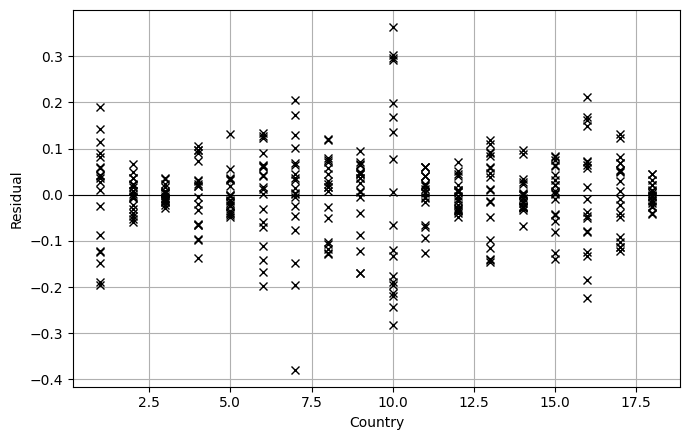

In [9]:
cn = np.arange(n) // nt + 1   # country index, 1..18

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cn, e, 'kx', linewidth=1.1)
ax.axhline(0, color='k', linewidth=0.8)
ax.grid(True)
ax.set_ylabel('Residual')
ax.set_xlabel('Country')
plt.tight_layout()
plt.show()


Then the weights are:

$$w_{i,t}= 1/\hat{\sigma}^{2}_{g}$$

**White Test**

$H_{0}:$ Homoscedasticity

In [10]:
print('White Test')
value, pvalue = my_white(e, X)
if pvalue < 0.05:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


White Test
Reject Homoscedasticity


**LR test (Breusch Pagan)**

$H_{0}:$ Homoscedasticity

In [11]:
print('BP test')
result = my_BP(e, X)
if result == 1:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


BP test
Reject Homoscedasticity


**Estimate FGLS**

In [12]:
beta_fgls, e_fgls, se_fgls = my_gls(Y, X, het=0, nt=nt, nc=nc)
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
                   'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
print(t.to_string(index=False))


       stat  beta_ols   se_ols   se_rob  beta_fgls  se_fgls
log(INC PC)  0.662250 0.071097 0.072774   0.575070 0.028354
 log(PRICE) -0.321702 0.042724 0.053813  -0.279671 0.034088
log(CAR PC) -0.640483 0.028753 0.038761  -0.565405 0.015632
         C1  2.285856 0.221203 0.226081   2.437067 0.109557
         C2  2.165551 0.206259 0.209831   2.316994 0.099057
         C3  3.041840 0.211816 0.224793   3.206521 0.112994
         C4  2.389456 0.201597 0.207829   2.547072 0.099305
         C5  2.204771 0.209719 0.210869   2.338616 0.097857
         C6  2.149868 0.211089 0.218463   2.300656 0.105530
         C7  2.337110 0.208183 0.218006   2.572089 0.108560
         C8  2.592325 0.236086 0.234701   2.723758 0.110287
         C9  2.232548 0.232070 0.229729   2.348050 0.104585
        C10  2.375927 0.205229 0.226428   2.589879 0.114525
        C11  2.234791 0.207493 0.213112   2.396188 0.101508
        C12  2.216701 0.196710 0.203004   2.384863 0.096395
        C13  1.681777 0.157397 0.171331 

**Estimate FGLS: Inverse variance weight**

In [13]:
beta_fgls, e_fgls, se_fgls = my_gls(Y, X, het=1)
t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
                   'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
print(t.to_string(index=False))


       stat  beta_ols   se_ols   se_rob  beta_fgls  se_fgls
log(INC PC)  0.662250 0.071097 0.072774   0.648836 0.010141
 log(PRICE) -0.321702 0.042724 0.053813  -0.311722 0.005354
log(CAR PC) -0.640483 0.028753 0.038761  -0.628395 0.005636
         C1  2.285856 0.221203 0.226081   2.328554 0.029097
         C2  2.165551 0.206259 0.209831   2.194592 0.025651
         C3  3.041840 0.211816 0.224793   3.075328 0.027824
         C4  2.389456 0.201597 0.207829   2.417507 0.025187
         C5  2.204771 0.209719 0.210869   2.231147 0.025489
         C6  2.149868 0.211089 0.218463   2.182425 0.027327
         C7  2.337110 0.208183 0.218006   2.381889 0.027041
         C8  2.592325 0.236086 0.234701   2.628616 0.029047
         C9  2.232548 0.232070 0.229729   2.258744 0.028327
        C10  2.375927 0.205229 0.226428   2.420703 0.027214
        C11  2.234791 0.207493 0.213112   2.265657 0.025942
        C12  2.216701 0.196710 0.203004   2.249052 0.024314
        C13  1.681777 0.157397 0.171331 

**Activity 2: Spurious Relations**

**The case of non-stationary series**

Construct two independent random walk processes

$$y_{t} = y_{t-1}+\epsilon_{y}$$

$$x_{t} = x_{t-1}+\epsilon_{x}$$

Where $\epsilon_{y}$ and $\epsilon_{x}\sim\mathcal{N}(0,1)$

In [14]:
rng = np.random.default_rng(123)
n = 100
y = np.zeros(n)
x = np.zeros(n)
ey = rng.standard_normal(n)
ex = rng.standard_normal(n)

for i in range(1, n):
    y[i] = y[i - 1] + ey[i]
    x[i] = x[i - 1] + ex[i]

# Running Regression
X = np.column_stack([np.ones(n), x])
beta_ols, sigma, e, se_ols, se_rob = my_ols(y, X)

stat = ['beta']
t = pd.DataFrame({'stat': stat, 'beta': [beta_ols[1]], 'se': [se_ols[1]]})
print(t.to_string(index=False))


stat     beta       se
beta 0.533732 0.040337


Visual inspection

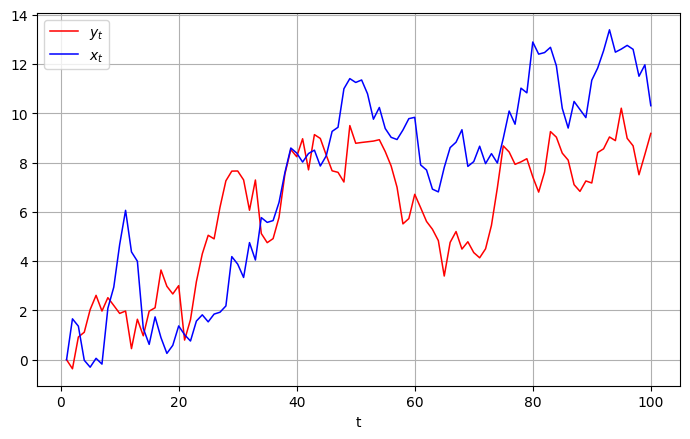

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.grid(True)
ax.plot(np.arange(1, n + 1), y, 'r-', linewidth=1.1, label='$y_t$')
ax.plot(np.arange(1, n + 1), x, 'b-', linewidth=1.1, label='$x_t$')
ax.legend()
ax.set_xlabel('t')
plt.tight_layout()
plt.show()


**Detrending the variables**

In [16]:
yd = y[1:] - y[:-1]
xd = x[1:] - x[:-1]


Visual inspection

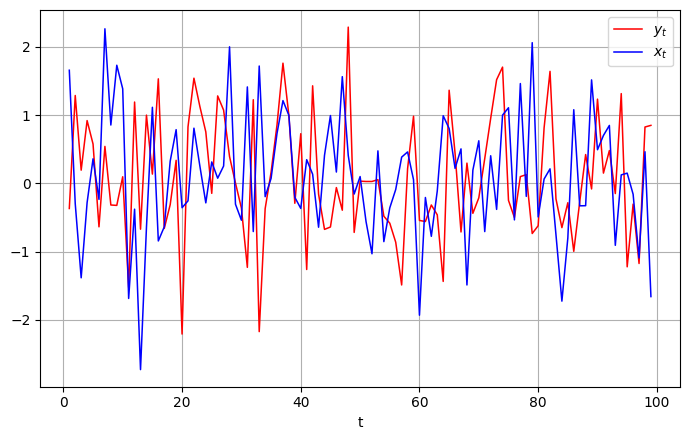

stat     beta       se
beta 0.046421 0.097625


In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.grid(True)
ax.plot(np.arange(1, n), yd, 'r-', linewidth=1.1, label='$y_t$')
ax.plot(np.arange(1, n), xd, 'b-', linewidth=1.1, label='$x_t$')
ax.legend()
ax.set_xlabel('t')
plt.tight_layout()
plt.show()

# Running Regression
Xd = np.column_stack([np.ones(n - 1), xd])
beta_ols, sigma, e, se_ols, se_rob = my_ols(yd, Xd)

stat = ['beta']
t = pd.DataFrame({'stat': stat, 'beta': [beta_ols[1]], 'se': [se_ols[1]]})
print(t.to_string(index=False))


This markdown was constructed based on the IPYNB code below.

In [18]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
#
#
# def my_ols(y, x):
#     '''
#     This function computes OLS estimates and
#     its standard errors
#     inputs: y dependent var
#             x independent vars
#     outputs: beta   OLS coefficients
#              sigma  Estimator or variance of error
#              e      Backed residuals
#              se     Standard Errors
#     '''
#     n, k = x.shape
#     beta = np.linalg.lstsq(x, y, rcond=None)[0]
#     e = y - x @ beta
#     sigma = (e @ e) / (n - np.linalg.matrix_rank(x))
#     VCV = (e @ e) / n * np.linalg.inv(x.T @ x)
#     se = np.sqrt(np.diag(VCV))
#
#     # Eicker-White se
#     aux = x * (e ** 2)[:, None]
#     VCV_white = np.linalg.inv(x.T @ x) @ (x.T @ aux) @ np.linalg.inv(x.T @ x)
#     se_rob = np.sqrt(np.diag(VCV_white))
#
#     return beta, sigma, e, se, se_rob
#
#
# def my_gls(y, x, x_aux=None, het=0, nt=None, nc=None):
#     '''
#     This function computes GLS estimates and
#     its standard errors
#     inputs: y dependent var
#             x independent vars
#     outputs: beta   OLS coefficients
#              sigma  Estimator or variance of error
#              e      Backed residuals
#              se     Standard Errors
#     '''
#     n, k = x.shape
#     if het == 1:
#         # Traditional heteroskedasticity
#         _, _, e_ols, _, _ = my_ols(y, x)
#         e_ols = e_ols ** 2
#         # C = diag(1./ sqrt(e_ols));
#         L = np.linalg.cholesky(np.linalg.inv(np.diag(e_ols)))
#         C = L.T
#         beta, _, e, se, _ = my_ols(C @ y, C @ x)
#     elif het == 2:
#         # AR(1) Errors
#         _, _, e_ols, _, _ = my_ols(y, x)
#         ey = e_ols[1:n]
#         ex = e_ols[0:n - 1]
#         rho = (ex @ ey) / (ex @ ex)    # Estimating the autocorrelation coeff
#         e_auto = ey - ex * rho
#         var_e = e_auto.var(ddof=0)
#
#         sigma_e = np.eye(n)
#         for i in range(n):
#             for j in range(i + 1, n):
#                 sigma_e[i, j] = rho ** (j - i)
#                 sigma_e[j, i] = sigma_e[i, j]
#         L = np.linalg.cholesky(np.linalg.inv(sigma_e))
#         C = L.T
#         beta, _, e, se, _ = my_ols(C @ y, C @ x)
#     elif het == 3:
#         # Weighted Least Squares:
#         _, _, e_ols, _, _ = my_ols(y, x)
#         ye = np.log(e_ols ** 2)
#         xe = np.column_stack([np.ones(n), x_aux])
#         c, _, _, _, _ = my_ols(ye, xe)
#         wgt = np.exp(-c[0] - c[1] * x_aux)
#         beta, _, e, se, _ = my_ols(y * np.sqrt(wgt), x * np.sqrt(wgt)[:, None])
#     else:
#         # By group
#         _, _, e_ols, _, _ = my_ols(y, x)
#         e_aux = e_ols ** 2
#         e_aux = e_aux.reshape(nt, nc, order='F')
#         e_aux = e_aux.mean(axis=0)
#         e_aux = np.tile(e_aux, (nt, 1))
#         wgt = 1 / e_aux.flatten(order='F')
#         beta, _, e, se, _ = my_ols(y * np.sqrt(wgt), x * np.sqrt(wgt)[:, None])
#
#     return beta, e, se
#
#
# def my_white(e, x):
#     '''
#     White's test for heteroscedasticity
#     Input:
#     e: Residuals
#     x: Independent Variables
#     '''
#     n = e.shape[0]
#     k = x.shape[1] - 1
#     _, _, e_ols, _, _ = my_ols(e ** 2, x)
#     TSS = e ** 2 - (e ** 2).mean()
#     TSS = TSS @ TSS
#     ESS = e_ols @ e_ols
#     rsq = 1 - ESS / TSS
#     value = n * rsq
#     pvalue = 1 - stats.chi2.cdf(value, k)
#     return value, pvalue
#
#
# def my_BP(e, x):
#     '''
#     Breusch pagan test for heteroscedasticity
#     Input:
#     e: Residuals
#     x: Independent Variables
#     '''
#     n = e.shape[0]
#     k = x.shape[1]
#     g = (e ** 2) / ((e @ e) / n) - 1
#     xx_inv = np.linalg.inv(x.T @ x)
#     LM = 0.5 * (g @ x @ xx_inv @ x.T @ g)
#     crit = stats.chi2.ppf(0.95, k)
#     result = 1 if LM > crit else 0   # 1: Reject Ho, 0: Cannot Reject H0
#     return result
#
#
# # ----- next cell -----
#
# data_harvey = pd.read_csv('data_harvey.csv')
#
# X = np.column_stack([
#     np.ones(len(data_harvey)),
#     np.log(data_harvey['Q']),
#     np.log(data_harvey['Q']) ** 2,
#     np.log(data_harvey['PF']),
# ])
# Y = np.log(data_harvey['C']).to_numpy()
# X_aux = data_harvey['LF'].to_numpy()
# beta_ols, sigma, e, se_ols, se_rob = my_ols(Y, X)
#
# stat = ['Constant', 'log(Output)', 'log(Output^2)', 'log(Price Fuel)']
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(X_aux, e, 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.grid(True)
# ax.set_ylim(-0.4, 0.4)
# ax.set_ylabel('Residual')
# ax.set_xlabel('Load Factor')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# print('White Test')
# value, pvalue = my_white(e, X)
# t = pd.DataFrame({'pvalue': [pvalue]})
# print(t.to_string(index=False))
# if pvalue < 0.05:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# print('BP test')
# result = my_BP(e, X)
# if result == 1:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# beta_fgls, e_fgls, se_fgls = my_gls(Y, X, X_aux, het=3)
# stat = ['Constant', 'log(Output)', 'log(Output^2)', 'log(Price Fuel)']
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
#                    'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# beta_fgls, e_fgls, se_fgls = my_gls(Y, X, X_aux, het=1)
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
#                    'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# data_oecd = pd.read_csv('data_OECD.csv')
# nc = 18   # Number of countries
# nt = 19   # Number of years
#
# # Create Country dummy variables:
# n = nc * nt
# Xdum = np.zeros((n, nc))
# for i in range(nc):
#     lv = i * nt
#     uv = (i + 1) * nt
#     Xdum[lv:uv, i] = 1
#
# Y = data_oecd['lgaspcar'].to_numpy()
# X = np.column_stack([
#     data_oecd['lincomep'].to_numpy(),
#     data_oecd['lrpmg'].to_numpy(),
#     data_oecd['lcarpcap'].to_numpy(),
#     Xdum,
# ])
#
# beta_ols, sigma, e, se_ols, se_rob = my_ols(Y, X)
#
# stat = ['log(INC PC)', 'log(PRICE)', 'log(CAR PC)'] + [f'C{i+1}' for i in range(nc)]
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# cn = np.arange(n) // nt + 1   # country index, 1..18
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.plot(cn, e, 'kx', linewidth=1.1)
# ax.axhline(0, color='k', linewidth=0.8)
# ax.grid(True)
# ax.set_ylabel('Residual')
# ax.set_xlabel('Country')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# print('White Test')
# value, pvalue = my_white(e, X)
# if pvalue < 0.05:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# print('BP test')
# result = my_BP(e, X)
# if result == 1:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# beta_fgls, e_fgls, se_fgls = my_gls(Y, X, het=0, nt=nt, nc=nc)
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
#                    'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# beta_fgls, e_fgls, se_fgls = my_gls(Y, X, het=1)
# t = pd.DataFrame({'stat': stat, 'beta_ols': beta_ols, 'se_ols': se_ols, 'se_rob': se_rob,
#                    'beta_fgls': beta_fgls, 'se_fgls': se_fgls})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# rng = np.random.default_rng(123)
# n = 100
# y = np.zeros(n)
# x = np.zeros(n)
# ey = rng.standard_normal(n)
# ex = rng.standard_normal(n)
#
# for i in range(1, n):
#     y[i] = y[i - 1] + ey[i]
#     x[i] = x[i - 1] + ex[i]
#
# # Running Regression
# X = np.column_stack([np.ones(n), x])
# beta_ols, sigma, e, se_ols, se_rob = my_ols(y, X)
#
# stat = ['beta']
# t = pd.DataFrame({'stat': stat, 'beta': [beta_ols[1]], 'se': [se_ols[1]]})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.grid(True)
# ax.plot(np.arange(1, n + 1), y, 'r-', linewidth=1.1, label='$y_t$')
# ax.plot(np.arange(1, n + 1), x, 'b-', linewidth=1.1, label='$x_t$')
# ax.legend()
# ax.set_xlabel('t')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# yd = y[1:] - y[:-1]
# xd = x[1:] - x[:-1]
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.grid(True)
# ax.plot(np.arange(1, n), yd, 'r-', linewidth=1.1, label='$y_t$')
# ax.plot(np.arange(1, n), xd, 'b-', linewidth=1.1, label='$x_t$')
# ax.legend()
# ax.set_xlabel('t')
# plt.tight_layout()
# plt.show()
#
# # Running Regression
# Xd = np.column_stack([np.ones(n - 1), xd])
# beta_ols, sigma, e, se_ols, se_rob = my_ols(yd, Xd)
#
# stat = ['beta']
# t = pd.DataFrame({'stat': stat, 'beta': [beta_ols[1]], 'se': [se_ols[1]]})
# print(t.to_string(index=False))